# Repeated Encoding Basics

This notebook explains the repeated data re-encoding idea used in the Lumix optical-network experiments.

Audience: readers familiar with vectors, complex numbers, and basic neural-network training.

Learning goals:

1. Represent phase-only data encoding as both a vector mask and a diagonal matrix.
2. Follow a three-layer repeated optical pass numerically.
3. See why the system is linear in the optical field for fixed data, but nonlinear as a function of the data.
4. Recognize the Flax module shape used in later notebooks.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"Project root: {ROOT}")

RNG_SEED = 7

try:
    import numpy as np
    np.random.seed(RNG_SEED)
except ImportError:
    pass

print(f"Deterministic seed: {RNG_SEED}")


Project root: /Volumes/Storage/Github/Lumix
Deterministic seed: 7


## The Update Rule

For a real data vector `x`, phase-only encoding creates

```text
m(x) = exp(i alpha x)
D(x) = diag(m(x))
```

Applying the data to the optical field is elementwise multiplication:

```text
D(x) h = m(x) * h
```

The repeated unitary model applies this before every optical layer:

```text
h_l = U_l D(x) h_{l-1}
```


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

alpha = np.pi
x = np.array([0.00, 0.25, 0.50, 0.75])
mask = np.exp(1j * alpha * x)
D = np.diag(mask)
h0 = np.ones(4, dtype=complex) / np.sqrt(4)

print("x:", x)
print("m(x):", mask)
print("D(x) shape:", D.shape)
print("D(x) h0 equals m(x) * h0:", np.allclose(D @ h0, mask * h0))


x: [0.   0.25 0.5  0.75]
m(x): [ 1.    +0.j      0.7071+0.7071j  0.    +1.j     -0.7071+0.7071j]
D(x) shape: (4, 4)
D(x) h0 equals m(x) * h0: True


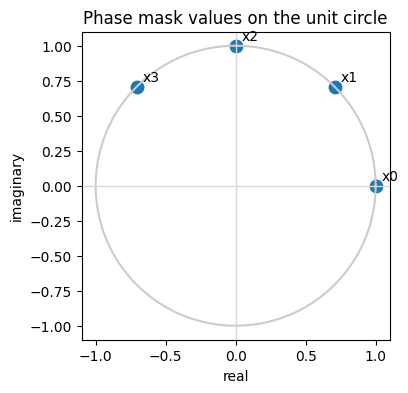

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
theta = np.linspace(0, 2 * np.pi, 256)
ax.plot(np.cos(theta), np.sin(theta), color="0.8")
ax.scatter(mask.real, mask.imag, s=80)
for idx, value in enumerate(mask):
    ax.text(value.real + 0.04, value.imag + 0.04, f"x{idx}")
ax.axhline(0, color="0.85", lw=1)
ax.axvline(0, color="0.85", lw=1)
ax.set_aspect("equal")
ax.set_title("Phase mask values on the unit circle")
ax.set_xlabel("real")
ax.set_ylabel("imaginary")
plt.show()


## A Three-Layer Numerical Pass

The following fixed matrices are simple unitaries used only to make the computation inspectable. In the trained model, the `U_l` matrices are learned and then held fixed at inference time.


In [4]:
H = 0.5 * np.array(
    [[1, 1, 1, 1], [1, -1, 1, -1], [1, 1, -1, -1], [1, -1, -1, 1]],
    dtype=complex,
)
F = 0.5 * np.array(
    [[1, 1, 1, 1], [1, -1j, -1, 1j], [1, -1, 1, -1], [1, 1j, -1, -1j]],
    dtype=complex,
)
P = np.array(
    [[0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]],
    dtype=complex,
)

fields = [h0]
encoded_fields = []
h = h0.copy()
for U in [H, F, P]:
    encoded = mask * h
    h = U @ encoded
    encoded_fields.append(encoded)
    fields.append(h)

for layer_index, (encoded, field) in enumerate(zip(encoded_fields, fields[1:]), start=1):
    print(f"encoded {layer_index}:", encoded)
    print(f"h{layer_index}:", field)

final_intensity = np.abs(fields[-1]) ** 2
print("final intensity:", final_intensity)
print("total power:", final_intensity.sum())


encoded 1: [ 0.5   +0.j      0.3536+0.3536j  0.    +0.5j    -0.3536+0.3536j]
h1: [ 0.25  +0.6036j  0.25  -0.1036j  0.6036-0.25j   -0.1036-0.25j  ]
encoded 2: [0.25+0.6036j 0.25+0.1036j 0.25+0.6036j 0.25+0.1036j]
h2: [ 0.5+0.7071j -0. -0.j      0. +0.5j    -0. +0.j    ]
encoded 3: [ 0.5+0.7071j -0. -0.j     -0.5+0.j      0. -0.j    ]
h3: [-0. -0.j     -0.5+0.j      0. -0.j      0.5+0.7071j]
final intensity: [0.   0.25 0.   0.75]
total power: 0.9999999999999997


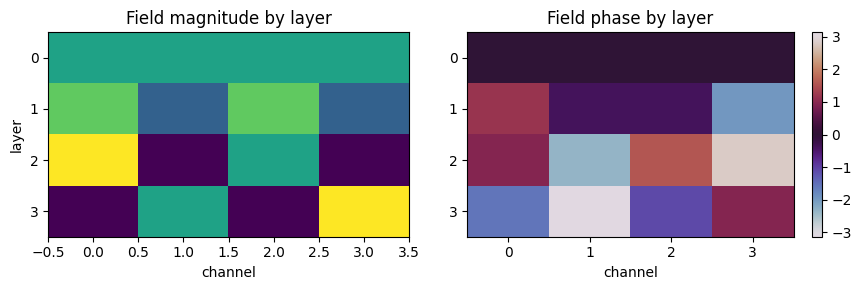

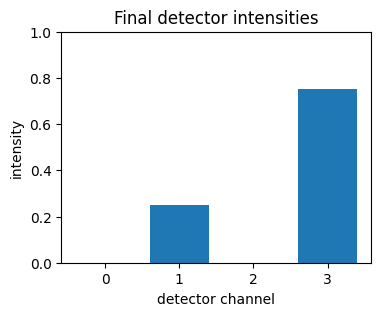

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(np.abs(np.stack(fields)), aspect="auto", cmap="viridis")
axes[0].set_title("Field magnitude by layer")
axes[0].set_xlabel("channel")
axes[0].set_ylabel("layer")

phase_image = np.angle(np.stack(fields))
im = axes[1].imshow(phase_image, aspect="auto", cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[1].set_title("Field phase by layer")
axes[1].set_xlabel("channel")
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
plt.bar(range(4), final_intensity)
plt.ylim(0, 1)
plt.title("Final detector intensities")
plt.xlabel("detector channel")
plt.ylabel("intensity")
plt.show()


## Flax-Style Model Skeleton

The tutorials use Flax modules for architecture readability. The module below mirrors the math directly: initialize a uniform field, build one data phase mask, and reapply that mask before every trainable unitary layer.


In [6]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from lumix.linen import InformationEncoder, IntensityReadout, UnitaryLinear

class RepeatedUnitaryClassifier(nn.Module):
    width: int = 4
    depth: int = 3
    classes: int = 4
    alpha: float = float(jnp.pi)

    @nn.compact
    def __call__(self, x):
        encoder = InformationEncoder(mode="phase", normalize=False)
        phase_mask = encoder(self.alpha * x)
        amplitude = jnp.sqrt(jnp.asarray(1.0 / self.width, dtype=jnp.float32))
        fields = jnp.full((*x.shape[:-1], self.width), amplitude, dtype=jnp.complex64)

        for layer_index in range(self.depth):
            fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields * phase_mask)

        intensities = IntensityReadout()(fields)
        return intensities[..., : self.classes]

model = RepeatedUnitaryClassifier()
variables = model.init(jax.random.key(RNG_SEED), jnp.asarray(x[None, :], dtype=jnp.float32))
print("parameter groups:", variables["params"].keys())
print("output intensities:", model.apply(variables, jnp.asarray(x[None, :], dtype=jnp.float32)))


parameter groups: dict_keys(['unitary_0', 'unitary_1', 'unitary_2'])
output intensities: [[0.2547 0.315  0.2032 0.2271]]


## Exercise

Change `alpha` from `pi` to `0.5*pi` in the numerical example. Before running it, predict whether the final intensity pattern should stay the same.

Answer scaffold: it should generally change, because the phase mask changes and the same learned optical matrices now interfere with different phases.
